In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_20newsgroups
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import nltk
import re


In [ ]:
# Download NLTK stopwords
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

# Initialize stop words and stemmer
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

# Preprocessing function
def preprocess_text(text):
    text = re.sub(r'\W', ' ', text)  # Remove non-alphanumeric characters
    text = text.lower()  # Convert to lowercase
    words = [stemmer.stem(word) for word in text.split() if word not in stop_words]
    return ' '.join(words)


In [ ]:
# Fetch 20 Newsgroups data and divide into 3 datasets to simulate different topic groups
categories1 = ['alt.atheism', 'comp.graphics', 'comp.os.ms-windows.misc', 'comp.sys.ibm.pc.hardware',
               'comp.sys.mac.hardware', 'comp.windows.x', 'misc.forsale']
categories2 = ['rec.autos', 'rec.motorcycles', 'rec.sport.baseball', 'rec.sport.hockey',
               'sci.crypt', 'sci.electronics', 'sci.med']
categories3 = ['sci.space', 'soc.religion.christian', 'talk.politics.guns',
               'talk.politics.mideast', 'talk.politics.misc', 'talk.religion.misc']

# Load different subsets
data1 = fetch_20newsgroups(subset='all', categories=categories1, shuffle=True, random_state=42)
data2 = fetch_20newsgroups(subset='all', categories=categories2, shuffle=True, random_state=42)
data3 = fetch_20newsgroups(subset='all', categories=categories3, shuffle=True, random_state=42)

# Create DataFrames for each simulated dataset and preprocess text
df1 = pd.DataFrame({'text': [preprocess_text(text) for text in data1.data], 'category': data1.target})
df2 = pd.DataFrame({'text': [preprocess_text(text) for text in data2.data], 'category': data2.target})
df3 = pd.DataFrame({'text': [preprocess_text(text) for text in data3.data], 'category': data3.target})


In [ ]:
# Define function to train and evaluate models with hyperparameter tuning
def train_and_evaluate_models(df, dataset_name):
    # Vectorize the text data
    vectorizer = CountVectorizer(max_features=4000, stop_words='english')
    X = vectorizer.fit_transform(df['text']).toarray()
    y = df['category']

    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    # Define parameter grids for hyperparameter tuning
    param_grid_svm = {
        'C': [0.1, 1, 10],
        'kernel': ['linear', 'rbf'],
        'gamma': ['scale', 'auto']
    }
    param_grid_nb = {'alpha': [0.1, 0.5, 1.0, 2.0]}
    param_grid_lr = {'C': [0.1, 1, 10], 'solver': ['liblinear', 'lbfgs']}

    # Initialize models with GridSearchCV
    grid_search_svm = GridSearchCV(SVC(), param_grid_svm, cv=5, scoring='accuracy', n_jobs=-1)
    grid_search_nb = GridSearchCV(MultinomialNB(), param_grid_nb, cv=5, scoring='accuracy', n_jobs=-1)
    grid_search_lr = GridSearchCV(LogisticRegression(max_iter=200), param_grid_lr, cv=5, scoring='accuracy', n_jobs=-1)

    # Fit models
    grid_search_svm.fit(X_train, y_train)
    grid_search_nb.fit(X_train, y_train)
    grid_search_lr.fit(X_train, y_train)

    # Get best estimators
    best_svm = grid_search_svm.best_estimator_
    best_nb = grid_search_nb.best_estimator_
    best_lr = grid_search_lr.best_estimator_

    # Evaluate each model on the test data
    y_pred_svm = best_svm.predict(X_test)
    y_pred_nb = best_nb.predict(X_test)
    y_pred_lr = best_lr.predict(X_test)

    # Store metrics
    results = {
        f'{dataset_name} - SVM': {
            'Accuracy': accuracy_score(y_test, y_pred_svm),
            'Precision': precision_score(y_test, y_pred_svm, average='macro'),
            'Recall': recall_score(y_test, y_pred_svm, average='macro'),
            'F1 Score': f1_score(y_test, y_pred_svm, average='macro')
        },
        f'{dataset_name} - Naive Bayes': {
            'Accuracy': accuracy_score(y_test, y_pred_nb),
            'Precision': precision_score(y_test, y_pred_nb, average='macro'),
            'Recall': recall_score(y_test, y_pred_nb, average='macro'),
            'F1 Score': f1_score(y_test, y_pred_nb, average='macro')
        },
        f'{dataset_name} - Logistic Regression': {
            'Accuracy': accuracy_score(y_test, y_pred_lr),
            'Precision': precision_score(y_test, y_pred_lr, average='macro'),
            'Recall': recall_score(y_test, y_pred_lr, average='macro'),
            'F1 Score': f1_score(y_test, y_pred_lr, average='macro')
        }
    }

    return results

In [ ]:
# Train and evaluate models for each dataset
results1 = train_and_evaluate_models(df1, "Data1")
results2 = train_and_evaluate_models(df2, "Data2")
results3 = train_and_evaluate_models(df3, "Data3")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Model Comparison Results:
                              Accuracy  Precision    Recall  F1 Score
Data1 - SVM                  0.841000   0.850862  0.844965  0.845896
Data1 - Naive Bayes          0.754000   0.805844  0.763698  0.720904
Data1 - Logistic Regression  0.870000   0.874269  0.873248  0.873435
Data2 - SVM                  0.920345   0.920910  0.920301  0.919683
Data2 - Naive Bayes          0.944818   0.944046  0.944345  0.943993
Data2 - Logistic Regression  0.951056   0.950678  0.950388  0.950293
Data3 - SVM                  0.896947   0.896177  0.888511  0.890665
Data3 - Naive Bayes          0.912850   0.913918  0.902964  0.905375
Data3 - Logistic Regression  0.922392   0.924298  0.915385  0.917593


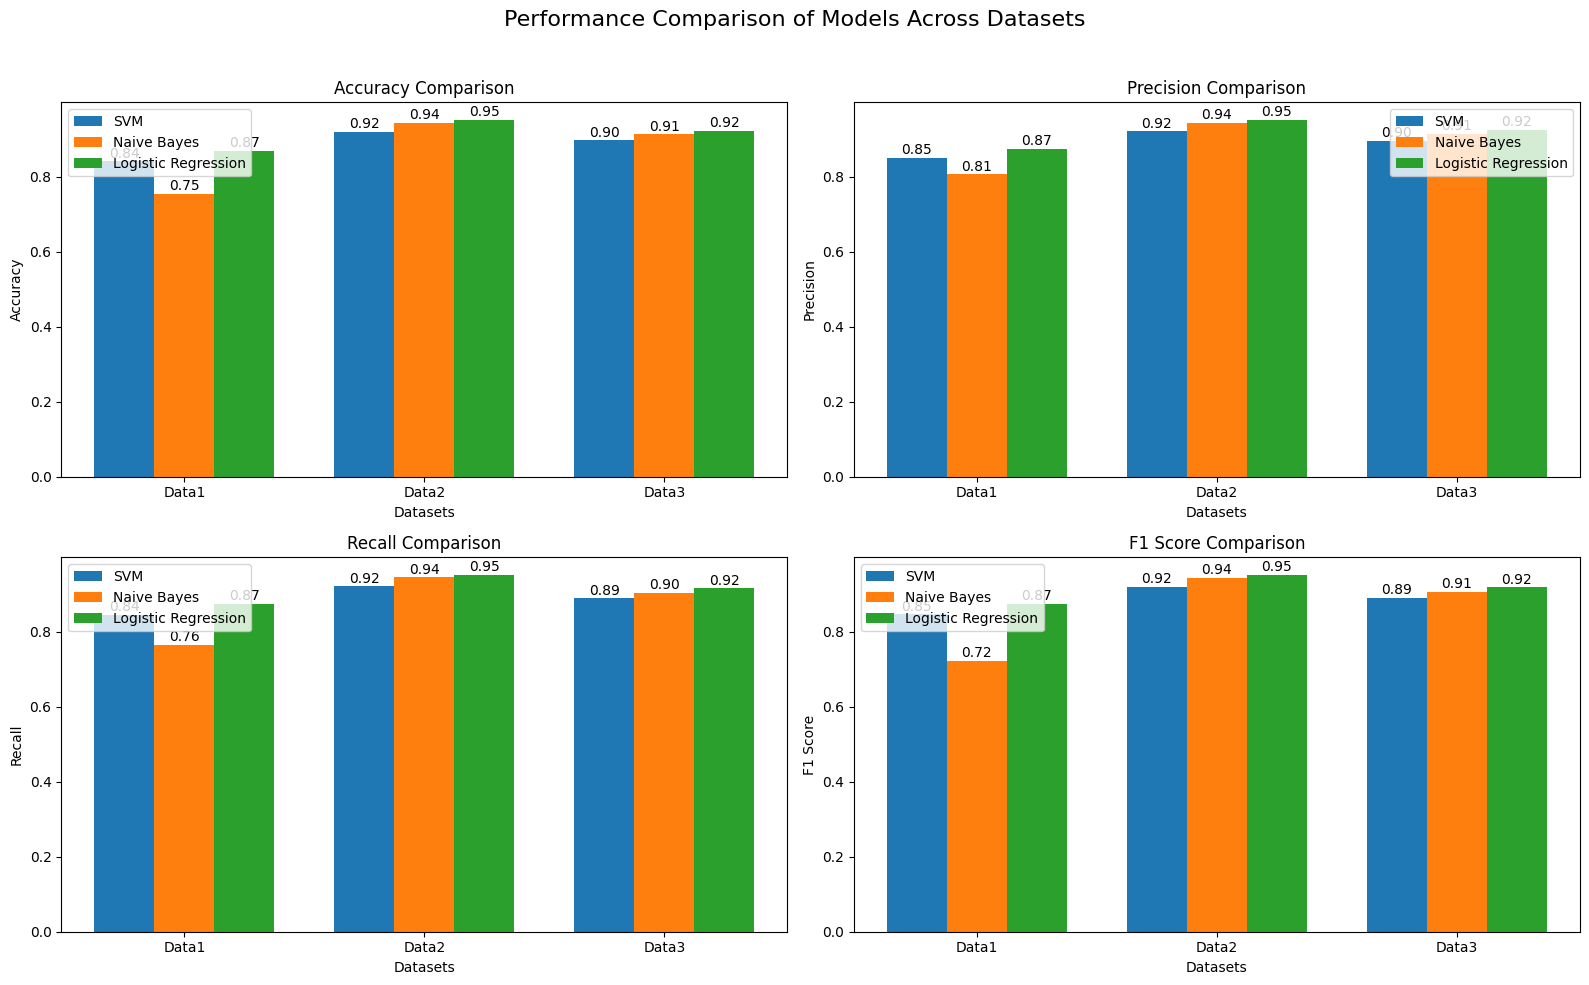

In [ ]:
# Combine all results
all_results = {**results1, **results2, **results3}
results_df = pd.DataFrame(all_results).T
print("Model Comparison Results:\n", results_df)

# Plotting the results for comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
fig, axs = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Performance Comparison of Models Across Datasets", fontsize=16)

# Plot each metric
for i, metric in enumerate(metrics):
    ax = axs[i // 2, i % 2]
    svm_scores = results_df[results_df.index.str.contains("SVM")][metric]
    nb_scores = results_df[results_df.index.str.contains("Naive Bayes")][metric]
    lr_scores = results_df[results_df.index.str.contains("Logistic Regression")][metric]

    x = np.arange(3)  # Number of datasets (Data1, Data2, Data3)
    width = 0.25  # Width of the bars

    # Plot bars for each model type
    ax.bar(x - width, svm_scores, width, label='SVM')
    ax.bar(x, nb_scores, width, label='Naive Bayes')
    ax.bar(x + width, lr_scores, width, label='Logistic Regression')

    # Labeling details
    ax.set_xlabel('Datasets')
    ax.set_ylabel(metric)
    ax.set_title(f'{metric} Comparison')
    ax.set_xticks(x)
    ax.set_xticklabels(['Data1', 'Data2', 'Data3'])
    ax.legend()

    # Adding text labels on top of bars
    for j in range(len(x)):
        ax.text(x[j] - width, svm_scores.iloc[j] + 0.01, f'{svm_scores.iloc[j]:.2f}', ha='center')
        ax.text(x[j], nb_scores.iloc[j] + 0.01, f'{nb_scores.iloc[j]:.2f}', ha='center')
        ax.text(x[j] + width, lr_scores.iloc[j] + 0.01, f'{lr_scores.iloc[j]:.2f}', ha='center')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [ ]:
# THE END #